# 1. A consumer with two nests

### Approach for Section 1.1

The consumer's problem is originally stated in quantities $(x_1, x_2, x_3)$
subject to the linear budget constraint

$$
p_1 x_1 + p_2 x_2 + p_3 x_3 = I,
$$

which a box-constrained solver like L-BFGS-B can't handle directly. Section
1.1 reparametrizes the choice into two numbers confined to $[0,1]$: $s_1$,
the share of income spent on food, and $w$, the share of the remaining
travel budget spent on the bus. The three budget shares then follow
automatically as

$$
s_1, \qquad s_2 = (1 - s_1) w, \qquad s_3 = (1 - s_1)(1 - w),
$$

which always sum to one, so the budget constraint holds for any choice in
the unit square — turning the constrained problem into a simple box
$[0,1] \times [0,1]$, exactly what L-BFGS-B takes as bounds, with no
penalty terms needed.

This mapping (`shares` and `quantities`) is already implemented in
`Consumer.py`, so our job is to understand why it works (linking to the
reparametrization idea from section 6.4 of the optimization lecture) and to
build the utility side of the problem on top of it:

- `utility(x1, x2, x3)` implements the nested CES formula

$$
x_B = \left[\beta x_2^{\rho_B} + (1-\beta) x_3^{\rho_B}\right]^{\frac{1}{\rho_B}},
\qquad
u(x_1, x_2, x_3) = \left[\alpha x_1^{\rho_A} + (1-\alpha) x_B^{\rho_A}\right]^{\frac{1}{\rho_A}},
$$

  combining goods 2 and 3 into the travel composite $x_B$ first, and then
  combining that with good 1.

- `value_of_choice(s1, w)` turns the nested shares into quantities using
  the given `quantities()` function and passes them to `utility()`, giving
  the objective that `solve_grid` and `solve` will later maximize.

In short, 1.1 sets up *what* is being maximized as a function of $(s_1, w)$,
not yet *how* it gets solved.

In [ ]:
# Following code is from Consumer.py - We have added our own code when stated in the comments

from types import SimpleNamespace

import numpy as np

from scipy import optimize

class ConsumerClass:
    """ a consumer with nested CES preferences over three goods

    Good 1 is food. Goods 2 and 3 are bus trips and train trips, and they sit
    together in a nest.

    The problem is written in *nested* budget shares, in the same two steps as
    the nests themselves:

        s1 = the share of income spent on food
        w  = the share of the remaining (travel) budget spent on the bus

    so that s2 = (1-s1)*w and s3 = (1-s1)*(1-w). Any (s1,w) in the unit square
    is a possible choice, and every possible choice is in the unit square, so
    the constraint set is exactly the box that L-BFGS-B takes as `bounds`.

    """

    def __init__(self,par=None):

        # a. setup
        self.setup()

        # b. update parameters
        if not par is None:
            for k,v in par.items():
                self.par.__dict__[k] = v

    def setup(self):
        """ set the baseline parameters """

        par = self.par = SimpleNamespace()
        sol = self.sol = SimpleNamespace()

        # a. preference weights
        par.alpha = 0.60 # weight on food
        par.beta = 0.50 # weight on the bus

        # b. substitution
        par.sigma_A = 0.80 # between food and travel (upper nest)
        par.sigma_B = 0.40 # between bus and train (lower nest)

        # c. prices and income
        par.p1 = 1.0 # price of food
        par.p2 = 1.0 # price of a bus trip
        par.p3 = 1.5 # price of a train trip
        par.I = 10.0 # income

        # d. numerical settings
        par.s_min = 1e-12 # smallest quantity allowed in .ces(), see the note there

    def __str__(self):
        """ print the parameters """

        par = self.par

        lines = ['ConsumerClass']
        lines.append(f'  alpha = {par.alpha:.4f}, beta = {par.beta:.4f}')
        lines.append(f'  sigma_A = {par.sigma_A:.4f}, sigma_B = {par.sigma_B:.4f}')
        lines.append(f'  p1 = {par.p1:.4f}, p2 = {par.p2:.4f}, p3 = {par.p3:.4f}')
        lines.append(f'  I = {par.I:.4f}')

        return '\n'.join(lines)

    ###################
    # 1. the CES nest #
    ###################

    def ces(self,z1,z2,w,sigma):
        """ the CES aggregate of two inputs

        Computes (w*z1**rho + (1-w)*z2**rho)**(1/rho) with rho = 1-1/sigma.

        The inputs are floored at par.s_min, because z**rho is not defined for
        z = 0 when rho < 0, and the corners of the unit square do give zeros.

        Note on the size of par.s_min. It must be *far* below the step that
        L-BFGS-B uses to estimate the gradient, which is `eps` and about 1e-8 by
        default. Otherwise both z and z+eps get floored to the same number near a
        bound, utility comes out exactly equal in the two points, the estimated
        gradient is zero, and the solver stops on the bound and stays there. With
        s_min = 1e-8 that really happens: the answers in section 4 for high tax
        rates come out as zero revenue. 1e-12 is small enough to be invisible and
        large enough to keep z**rho from overflowing.

        Args:

            z1 (float or ndarray): first input
            z2 (float or ndarray): second input
            w (float): weight on the first input
            sigma (float): substitution parameter, must not be 1

        Returns:

            (float or ndarray): the CES aggregate

        """

        par = self.par

        assert not np.isclose(sigma,1.0), 'sigma = 1 gives rho = 0 and a division by zero'

        z1 = np.maximum(z1,par.s_min)
        z2 = np.maximum(z2,par.s_min)

        rho = 1-1/sigma

        return (w*z1**rho + (1-w)*z2**rho)**(1/rho)

    def utility(self,x1,x2,x3):
        """ nested CES utility of a bundle of quantities

        Two steps: first combine goods 2 and 3 into the travel composite, then
        combine good 1 and the composite into utility. Use .ces() for both.

        Args:

            x1 (float or ndarray): quantity of good 1
            x2 (float or ndarray): quantity of good 2
            x3 (float or ndarray): quantity of good 3

        Returns:

            (float or ndarray): utility

        """

        par = self.par

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE TO GENERATE THE TRAVEL COMPOSITE AND THE UTILITY 
        #pass

        par = self.par
        
        xB = self.ces(x2, x3, par.beta, par.sigma_B)
                
        u = self.ces(x1, xB, par.alpha, par.sigma_A)

        return u

#-------------------------------------------------------------------------------------#

    ###############################
    # 2. the nested budget shares #
    ###############################

    def shares(self,s1,w):
        """ the three budget shares implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (tuple): the three budget shares, which always sum to one

        """

        return s1,(1-s1)*w,(1-s1)*(1-w)

    def quantities(self,s1,w):
        """ the quantities implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (tuple): the three quantities

        """

        par = self.par

        s1,s2,s3 = self.shares(s1,w)

        return s1*par.I/par.p1, s2*par.I/par.p2, s3*par.I/par.p3

    def value_of_choice(self,s1,w):
        """ utility of the bundle implied by the nested shares

        Args:

            s1 (float or ndarray): share of income spent on food
            w (float or ndarray): share of the travel budget spent on the bus

        Returns:

            (float or ndarray): utility

        """

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE. INSTEAD OF CHOOSING QUANTITIES, WE CHOOSE BUDGET SHARES. 

        #pass
        x1, x2, x3 = self.quantities(s1, w)
        u = self.utility(x1, x2, x3)

        return u
#-------------------------------------------------------------------------------------#

    def objective(self,s):
        """ minus utility, for a minimizer

        Nothing else is needed: the bounds are the whole constraint.

        Args:

            s (ndarray): array of length 2 with (s1,w)

        Returns:

            (float): minus utility

        """

        return -self.value_of_choice(s[0],s[1])

    #################
    # 3. solving it #
    #################

    def solve_grid(self,N=200,do_print=True):
        """ solve by a 2-dimensional grid search over the nested shares

        Every point of the unit square is a possible choice, so there is nothing
        to mask out here -- a plain np.argmax will do.

        Args:

            N (int): number of grid points for each variable
            do_print (bool): print the solution

        Returns:

            (SimpleNamespace): the grids, the utility values and the best point

        """

        par = self.par
        opt = SimpleNamespace()

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE. 

        # a. the two grids
        #pass
        s1_vec = np.linspace(0, 1, N)
        w_vec = np.linspace(0, 1, N)
    
        opt.s1_grid, opt.w_grid = np.meshgrid(
                s1_vec, w_vec, indexing='ij'
             )

        # b. utility in every grid point
        #pass
        opt.u_grid = self.value_of_choice(
                    opt.s1_grid,
                    opt.w_grid
                )

        # c. the best point
        #pass
        idx = np.unravel_index(
                   np.argmax(opt.u_grid),
                   opt.u_grid.shape
                )
        
        opt.s1 = opt.s1_grid[idx]
        opt.w = opt.w_grid[idx]
        
        opt.s2 = (1 - opt.s1) * opt.w
        opt.s3 = (1 - opt.s1) * (1 - opt.w)
        
        opt.u = opt.u_grid[idx]
    

        # d. results
        # opt.s1, opt.w, opt.s2, opt.s3, opt.u
        # opt.s1_grid, opt.w_grid, opt.u_grid (needed for the figures)

        return opt

#-------------------------------------------------------------------------------------#

    def solve(self,s0=None,do_print=True,**kwargs):
        """ solve with L-BFGS-B

        The bounds are ((0,1),(0,1)) -- the whole constraint set.

        Args:

            s0 (ndarray): starting guess for (s1,w)
            do_print (bool): print the solution
            kwargs: passed on to optimize.minimize, e.g. options={'ftol':1e-10}

        Returns:

            (SimpleNamespace): the solution and the convergence path

        """

        par = self.par
        opt = SimpleNamespace()

        # a. starting guess
        if s0 is None: s0 = np.array([0.5,0.5])
        s0 = np.asarray(s0,dtype=float)

        # b. record the path with a callback
        path = [s0.copy()]

#-------------------------------------------------------------------------------------#
# WE NOW ADD OUR OWN CODE
        # c. minimize
        #pass
        res = optimize.minimize(
               self.objective,
               s0,
               method='L-BFGS-B',
               bounds=((0,1),(0,1)),
               callback=lambda sk: path.append(sk.copy()),
               **kwargs
            )

        # d. results
        # opt.s1, opt.w, opt.s2, opt.s3, opt.u, opt.path, opt.res
        opt.s1 = res.x[0]
        opt.w = res.x[1]
        opt.s2 = (1 - opt.s1) * opt.w
        opt.s3 = (1 - opt.s1) * (1 - opt.w)
        opt.u = -res.fun
        opt.path = path
        opt.res = res

        return opt

#-------------------------------------------------------------------------------------#

In 1.1 we must rewrite the consumers optimization problem, so that Python choose two numbers (s1, w) instead of three quantities (x1, x2, x3)

Test Question 1

In [9]:
# Whoopi sanity check

model = ConsumerClass()
for s1_now,w_now in [(0.0,0.0),(0.3,0.5),(0.6,0.7),(1.0,1.0)]:
    x1,x2,x3 = model.quantities(s1_now,w_now)
    expenditure = model.par.p1*x1 + model.par.p2*x2 + model.par.p3*x3
    print(f's1={s1_now:.2f}, w={w_now:.2f}: x1={x1:6.3f}, x2={x2:6.3f}, x3={x3:6.3f}, expenditure={expenditure:.6f}')


s1=0.00, w=0.00: x1= 0.000, x2= 0.000, x3= 6.667, expenditure=10.000000
s1=0.30, w=0.50: x1= 3.000, x2= 3.500, x3= 2.333, expenditure=10.000000
s1=0.60, w=0.70: x1= 6.000, x2= 2.800, x3= 0.800, expenditure=10.000000
s1=1.00, w=1.00: x1=10.000, x2= 0.000, x3= 0.000, expenditure=10.000000


In [10]:
# Thongs sanity check
model = ConsumerClass()

grid_sol = model.solve_grid(N=500)

print("Grid solution:")
print("s1 =", grid_sol.s1)
print("w  =", grid_sol.w)
print("s2 =", grid_sol.s2)
print("s3 =", grid_sol.s3)
print("u  =", grid_sol.u)

Grid solution:
s1 = 0.5350701402805611
w  = 0.438877755511022
s2 = 0.20404737330372166
s3 = 0.26088248641571726
u  = 3.40167436585882


Compare with L-BFGS-B

In [3]:
sol = model.solve()

print("\nL-BFGS-B solution:")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("s2 =", sol.s2)
print("s3 =", sol.s3)
print("u  =", sol.u)


L-BFGS-B solution:
s1 = 0.5356233806953101
w  = 0.43947902810370126
s2 = 0.20408378532610758
s3 = 0.26029283397858227
u  = 3.401679875985606


In [4]:
sol.s1 + sol.s2 + sol.s3

np.float64(1.0)

### 1.2 Calibration


##### Approach for Section 1.2

Section 1.2 does not require new code, only running the existing model under
two calibrations that differ solely in $\sigma_B$: $\sigma_B = 0.40$ (bus and
train as complements) versus $\sigma_B = 3.00$ (substitutes), with all other
parameters held fixed. Since `ConsumerClass` already accepts a `par`
dictionary that overwrites only the given keys, the second calibration costs
one extra line,

```python
model_substitutes = ConsumerClass(par={'sigma_B': 3.0})
```

and every later step (solving, printing, plotting) can loop over both models
instead of duplicating code.

In [11]:
# Thong
model_sub = ConsumerClass(par={'sigma_B': 3.0})

In [12]:
# Whoopi
# a. the two calibrations
model_complements = ConsumerClass()                        # sigma_B = 0.40 (default)
model_substitutes = ConsumerClass(par={'sigma_B':3.0})     # sigma_B = 3.00, everything else unchanged

models = {'Complements':model_complements, 'Substitutes':model_substitutes}

# b. solve both the same way, no duplicated code
for name,model in models.items():

    opt = model.solve() # or model.solve_grid(), depending on what you've implemented so far

    print(f'--- {name} (sigma_B = {model.par.sigma_B:.2f}) ---')
    print(f's1 = {opt.s1:.4f}, w = {opt.w:.4f}')
    print(f's2 = {opt.s2:.4f}, s3 = {opt.s3:.4f}')
    print(f'u  = {opt.u:.4f}\n')

--- Complements (sigma_B = 0.40) ---
s1 = 0.5356, w = 0.4395
s2 = 0.2041, s3 = 0.2603
u  = 3.4017

--- Substitutes (sigma_B = 3.00) ---
s1 = 0.5382, w = 0.6923
s2 = 0.3197, s3 = 0.1421
u  = 3.4851



### 1.3 How do you know your answer is right?

There is no formula for the solution of this model, so you cannot look the answer up. Two cheap checks: 

1. Is the answer possible? All three shares should be strictly between 0 and 1 aand sum to one, and all three quantities should be positive

##### Approach for section 1.3


In [7]:
# Check that the solution is possible

print("Budget shares:")
print("s1 =", sol.s1)
print("s2 =", sol.s2)
print("s3 =", sol.s3)

print("\nSum of shares:")
print(sol.s1 + sol.s2 + sol.s3)

print("\nQuantities:")
x1, x2, x3 = model.quantities(sol.s1, sol.w)

print("x1 =", x1)
print("x2 =", x2)
print("x3 =", x3)

Budget shares:
s1 = 0.5356233806953101
s2 = 0.20408378532610758
s3 = 0.26029283397858227

Sum of shares:
1.0

Quantities:
x1 = 5.356233806953101
x2 = 2.040837853261076
x3 = 1.7352855598572152


Since all budget shares $0<s<1$, all quantites is positive, and the sum of shares = 1, the solution is possible

In [14]:
0 < sol.s1 < 1
0 < sol.s2 < 1
0 < sol.s3 < 1

NameError: name 'sol' is not defined

In [15]:
sol.s1 + sol.s2 + sol.s3

NameError: name 'sol' is not defined

In [16]:
x1 > 0
x2 > 0
x3 > 0

False

In [17]:
print("All shares between 0 and 1:",
      0 < sol.s1 < 1 and
      0 < sol.s2 < 1 and
      0 < sol.s3 < 1)

print("Shares sum to 1:",
      np.isclose(sol.s1 + sol.s2 + sol.s3, 1))

print("All quantities positive:",
      x1 > 0 and x2 > 0 and x3 > 0)

NameError: name 'sol' is not defined

2. Do two different methods agree? In section 2 you solve the same problem twice.

In [12]:
grid_sol = model.solve_grid(N=1000)
sol = model.solve()

# Grid search:
print("Grid search:")
print("s1 =", grid_sol.s1)
print("w  =", grid_sol.w)
print("u  =", grid_sol.u)

# L-BFGS-B optimization:
print("\nL-BFGS-B:")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("u  =", sol.u)

Grid search:
s1 = 0.5355355355355356
w  = 0.4394394394394394
u  = 3.4016797975402664

L-BFGS-B:
s1 = 0.5356233806953101
w  = 0.43947902810370126
u  = 3.401679875985606


The grid search only consider a finite number of points, so its result will not necessary be identical to L-BFGS-B. But with a sufficient fine grid, the results should be almost identical. 

In [13]:
# Calculate the difference 

print("Difference in s1:",
      abs(grid_sol.s1 - sol.s1))

print("Difference in w:",
      abs(grid_sol.w - sol.w))

print("Difference in utility:",
      abs(grid_sol.u - sol.u))

Difference in s1: 8.784515977455776e-05
Difference in w: 3.958866426184704e-05
Difference in utility: 7.844533955747579e-08


In [ ]:
grid_sol = model.solve_grid(N=1000)
sol = model.solve()

# Grid search:
print("Grid search:")
print("s1 =", grid_sol.s1)
print("w  =", grid_sol.w)
print("u  =", grid_sol.u)

# L-BFGS-B optimization:
print("\nL-BFGS-B:")
print("s1 =", sol.s1)
print("w  =", sol.w)
print("u  =", sol.u)

## 2. Solving the model numerically
We solve eq. 4 (utility maximization) twice, in two very different ways


### 2.1 A two-dimensional grid search

##### Approach for 2.1
In 2.1 we solve the utility maximization problem with a two-dimensional grid search. We lay a grid over everything the consumer can afford, compute utility in every point, and keep the best one.



 by the following approach

1. Create two vectors of `N` points between 0 and 1 — one for `s_1` and one for `w`.
2. Create a 2D grid of all combinations using `np.meshgrid(..., indexing='ij')`.
3. Calculate utility at **all** grid points at once (vectorized, so no loop is needed, because `ces()`, `utility()`, and `value_of_choice()` already work with arrays).
4. Find the best point using `np.argmax` + `np.unravel_index`.
5. Report both `(s_1, w)` and the three implied budget shares `(s_1, s_2, s_3)`.

In [9]:
# 1. Punkt 1: solve_grid() i Consumer.py

def solve_grid(self,N=200,do_print=True):
    """ solve by a 2-dimensional grid search over the nested shares

    Every point of the unit square is a possible choice, so there is nothing
    to mask out here -- a plain np.argmax will do.

    Args:

        N (int): number of grid points for each variable
        do_print (bool): print the solution

    Returns:

        (SimpleNamespace): the grids, the utility values and the best point

    """

    par = self.par
    opt = SimpleNamespace()

    # a. the two grids
    s1_vec = np.linspace(0,1,N)
    w_vec = np.linspace(0,1,N)
    s1_grid,w_grid = np.meshgrid(s1_vec,w_vec,indexing='ij')

    # b. utility in every grid point
    u_grid = self.value_of_choice(s1_grid,w_grid)

    # c. the best point
    i_best,j_best = np.unravel_index(np.argmax(u_grid),u_grid.shape)

    # d. results
    opt.s1 = s1_grid[i_best,j_best]
    opt.w = w_grid[i_best,j_best]
    opt.s1,opt.s2,opt.s3 = self.shares(opt.s1,opt.w)
    opt.u = u_grid[i_best,j_best]

    opt.s1_grid = s1_grid
    opt.w_grid = w_grid
    opt.u_grid = u_grid

    if do_print:
        print(f's1 = {opt.s1:.4f}, w = {opt.w:.4f}')
        print(f's1 = {opt.s1:.4f}, s2 = {opt.s2:.4f}, s3 = {opt.s3:.4f}')
        print(f'u  = {opt.u:.4f}')

    return opt



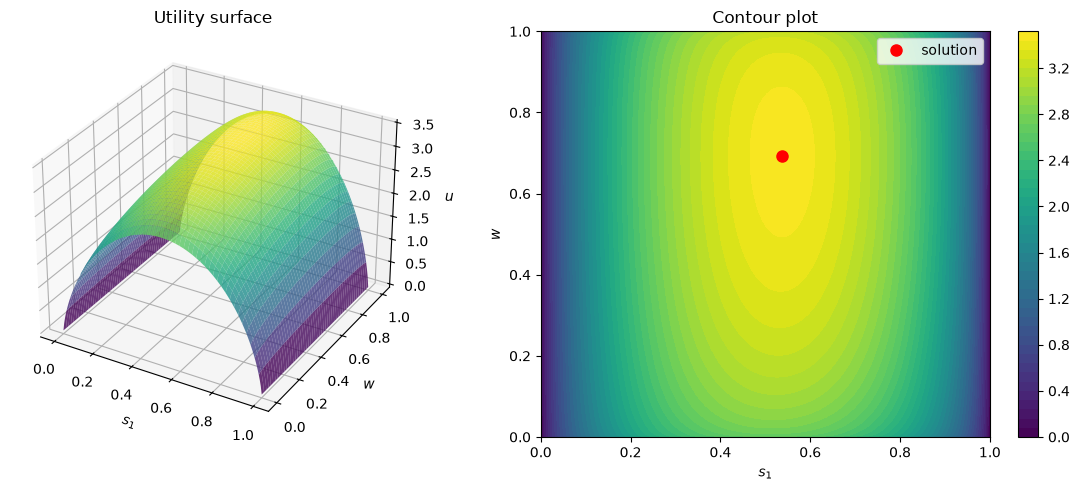

In [10]:
# 2. Punkt 2: 3D-overflade og contour plot med løsningen markeret

import matplotlib.pyplot as plt

opt = model.solve_grid(N=200)

fig = plt.figure(figsize=(12,5))

# a. 3D surface
ax = fig.add_subplot(1,2,1,projection='3d')
ax.plot_surface(opt.s1_grid,opt.w_grid,opt.u_grid,cmap='viridis',alpha=0.8)
ax.set_xlabel('$s_1$')
ax.set_ylabel('$w$')
ax.set_zlabel('$u$')
ax.set_title('Utility surface')

# b. contour plot with the solution marked
ax = fig.add_subplot(1,2,2)
cs = ax.contourf(opt.s1_grid,opt.w_grid,opt.u_grid,levels=50,cmap='viridis')
ax.plot(opt.s1,opt.w,'ro',markersize=8,label='solution')
ax.set_xlabel('$s_1$')
ax.set_ylabel('$w$')
ax.set_title('Contour plot')
ax.legend()

fig.colorbar(cs,ax=ax)
plt.tight_layout()
plt.show()





In [12]:
# 3. Compare N = 50, 100, 500, 1000 

print(f'{"N":>6s}{"s1":>12s}{"w":>12s}{"u":>14s}{"evals":>12s}')
for N in [50,100,500,1000]:

    opt = model.solve_grid(N=N,do_print=False)
    n_evals = N**2

    print(f'{N:>6d}{opt.s1:>12.6f}{opt.w:>12.6f}{opt.u:>14.8f}{n_evals:>12d}')


     N          s1           w             u       evals
    50    0.530612    0.693878    3.48459440        2500
   100    0.535354    0.696970    3.48500493       10000
   500    0.539078    0.691383    3.48509714      250000
  1000    0.538539    0.692693    3.48510354     1000000


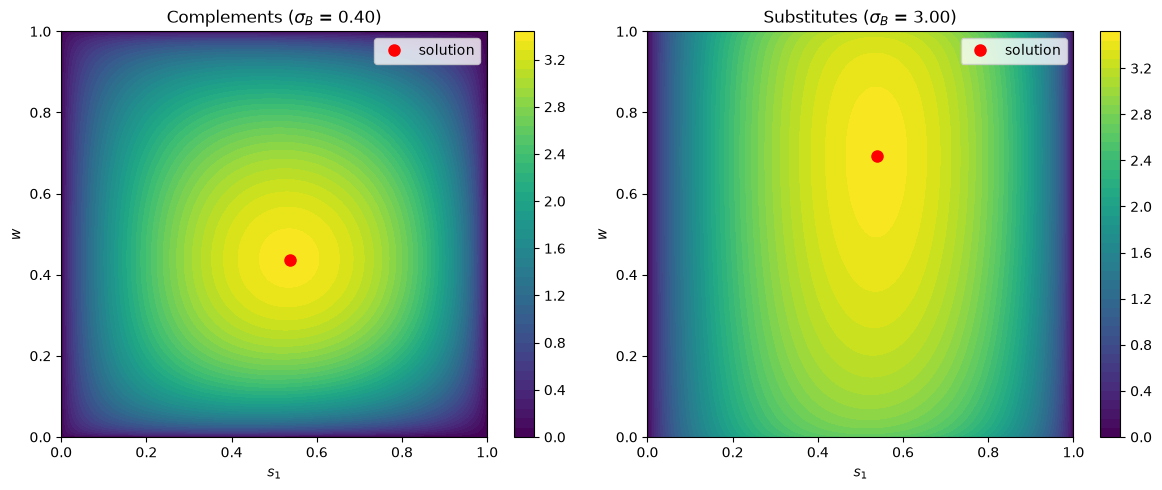

In [11]:
# 4 Compare calibrations 

model_complements = ConsumerClass()
model_substitutes = ConsumerClass(par={'sigma_B':3.0})

fig = plt.figure(figsize=(12,5))

for i,(name,m) in enumerate([('Complements',model_complements),('Substitutes',model_substitutes)]):

    opt = m.solve_grid(N=200,do_print=False)

    ax = fig.add_subplot(1,2,i+1)
    cs = ax.contourf(opt.s1_grid,opt.w_grid,opt.u_grid,levels=50,cmap='viridis')
    ax.plot(opt.s1,opt.w,'ro',markersize=8,label='solution')
    ax.set_xlabel('$s_1$')
    ax.set_ylabel('$w$')
    ax.set_title(f'{name} ($\\sigma_B$ = {m.par.sigma_B:.2f})')
    ax.legend()
    fig.colorbar(cs,ax=ax)

plt.tight_layout()
plt.show()

### 2.1 A two-dimensional grid search
In this task we utilize our knowledge from the optimization lecture: We lay a grid over everything the
consumer can afford, compute utility in every point, and keep the best one. 


##### 2.1.1 
Make a grid of N values of s1 and N values of w, both from 0 to 1.
Compute utility in every combination, and keep the best point.
Implement it as solve_grid ().
Report both (s1, w) and the three budget shares it implies.


### 2.2 L-BFGS-B

Now you need to solve the same model using a **proper optimizer** instead of a brute-force grid search — L-BFGS-B, a gradient-based solver for smooth problems with bounds.

Because in 1.1 you rewrote the problem in terms of nested budget shares, `(s_1, w) \in [0,1] \times [0,1]`, the entire constraint set is simply a box. There is nothing else to handle: no penalty functions, no projection, and no equality constraints — just

`bounds=((0,1),(0,1))`.

In [14]:
def solve(self,s0=None,do_print=True,**kwargs):
    """ solve with L-BFGS-B

    The bounds are ((0,1),(0,1)) -- the whole constraint set.

    Args:

        s0 (ndarray): starting guess for (s1,w)
        do_print (bool): print the solution
        kwargs: passed on to optimize.minimize, e.g. options={'ftol':1e-10}

    Returns:

        (SimpleNamespace): the solution and the convergence path

    """

    par = self.par
    opt = SimpleNamespace()

    # a. starting guess
    if s0 is None: s0 = np.array([0.5,0.5])
    s0 = np.asarray(s0,dtype=float)

    # b. record the path with a callback
    path = [s0.copy()]
    def callback(s):
        path.append(s.copy())

    # c. minimize
    res = optimize.minimize(self.objective,s0,method='L-BFGS-B',
        bounds=((0,1),(0,1)),callback=callback,**kwargs)

    # d. results
    opt.s1,opt.w = res.x
    opt.s1,opt.s2,opt.s3 = self.shares(opt.s1,opt.w)
    opt.u = -res.fun
    opt.path = np.array(path)
    opt.res = res

    if do_print:
        print(f'success: {res.success} - {res.message}')
        print(f's1 = {opt.s1:.4f}, w = {opt.w:.4f}')
        print(f's1 = {opt.s1:.4f}, s2 = {opt.s2:.4f}, s3 = {opt.s3:.4f}')
        print(f'u  = {opt.u:.4f}')
        print(f'evaluations: {res.nfev}')

    return opt

### 2.2.1 



2.2.1 - Sammenlign med Grid search

In [15]:
import time

# a. grid search
t0 = time.perf_counter()
opt_grid = model.solve_grid(N=500,do_print=False)
t_grid = time.perf_counter()-t0

# b. L-BFGS-B
t0 = time.perf_counter()
opt_lbfgsb = model.solve(do_print=False)
t_lbfgsb = time.perf_counter()-t0

# c. comparison
print(f'{"":>15s}{"s1":>12s}{"w":>12s}{"u":>14s}{"evals":>10s}{"time (s)":>12s}')
print(f'{"Grid (N=500)":>15s}{opt_grid.s1:>12.6f}{opt_grid.w:>12.6f}{opt_grid.u:>14.8f}{500**2:>10d}{t_grid:>12.6f}')
print(f'{"L-BFGS-B":>15s}{opt_lbfgsb.s1:>12.6f}{opt_lbfgsb.w:>12.6f}{opt_lbfgsb.u:>14.8f}{opt_lbfgsb.res.nfev:>10d}{t_lbfgsb:>12.6f}')

                         s1           w             u     evals    time (s)
   Grid (N=500)    0.539078    0.691383    3.48509714    250000    0.041999
       L-BFGS-B    0.538225    0.692308    3.48510459        27    0.004354
